# Create Identity Scaling figure
- create figure showing the infidelity scaling with second qubit detuning of the identity gate for rabi and ccd schemes
- should be general - ie interms of rabi frequency
- should be pretty - with descriptive title etc

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# lets me import from a different directory
import sys 
sys.path.append("/Users/archie/documents/year4/project/code")

import spin_tools.hamiltonians as hamiltonians
from spin_tools.gates import *
import spin_tools.quantum_tools as qt
from spin_tools.floquet_tools import ccd_floquet

In [3]:
turquoise, hot_pink = "#00CED1", "#FF31CE"


In [4]:
steel_blue, plum = "#4682B4", "#B44682"

In [5]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"""
        \usepackage{amsmath}""",
    "font.size": 14,
    "axes.labelsize": 14,
    "legend.fontsize": 13,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "figure.titlesize": 14,
    "axes.titlesize": 14,
})



In [6]:

import os
import sys


# --- PATH modification for TinyTeX (BEGIN) ---
tinytex_bin_path = os.path.expanduser("~/Library/TinyTeX/bin/universal-darwin")
if os.path.exists(tinytex_bin_path):
    if tinytex_bin_path not in os.environ['PATH']:
        os.environ['PATH'] = tinytex_bin_path + os.pathsep + os.environ['PATH']
        print(f"Added {tinytex_bin_path} to PATH for this Python session.")
    else:
        print(f"{tinytex_bin_path} already in PATH for this session.")
else:
    print(f"Warning: TinyTeX bin path not found at {tinytex_bin_path}. LaTeX rendering might fail.")
# --- PATH modification for TinyTeX (END) ---


# --- Matplotlib Configuration for LaTeX Integration ---
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"""
        \usepackage{amsmath}""",
    "font.size": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.titlesize": 12,
    "axes.titlesize": 10,
})



# --- Figure Dimensions for Your LaTeX Document ---
pt_to_inches = 1.0 / 72.27
latex_textwidth_pts = 469.75502 # Standard for A4 article, 10pt
latex_fig_width_inches =1 * latex_textwidth_pts * pt_to_inches  

# Calculate column width: (textwidth - columnsep) / 2
# Your LaTeX sets \columnsep to 0.75cm. Convert 0.75cm to points.
# column_sep_cm = 0.75
# column_sep_pts = column_sep_cm * (72.27 / 2.54) # 72.27 pts/inch, 2.54 cm/inch

# latex_column_width_pts = (latex_textwidth_pts - column_sep_pts) / 2

# # Set figure width to match the calculated column width
# latex_fig_width_inches = latex_column_width_pts * pt_to_inches


# latex_fig_height_inches = latex_fig_width_inches


Added /Users/archie/Library/TinyTeX/bin/universal-darwin to PATH for this Python session.


# CCD

In [ ]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005


# CCD parameters
phi_0, epsilon_m, phase_freq, theta_m = 0, rabi_freq/4, rabi_freq, 0


# Integration parameters
tol = 10**-12
evaluation_points = 2000
evaluation_time = 4/rabi_freq

# iteration parameters
detunings = np.linspace(0, 100*rabi_freq, 2000)

fids_1 = []
fids_2 = []
fids_combined = []

# First calculate fidelity for qubit 1 (root-x gate)
times, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, hamiltonians.ccd_rwa,
                            driving_freq=driving_freq,
                            natural_freq=natural_freq, 
                            rabi_freq=rabi_freq, 
                            phi_0=phi_0,
                            epsilon_m=epsilon_m,
                            phase_freq=phase_freq,
                            theta_m=theta_m,
                            atol=tol,
                            rtol=tol)
fid_1 = qt.calculate_fidelities(identity, Us_driving_frame, 2)

# For each detuning, calculate fidelity for qubit 2 (identity gate)
for detuning in detunings:
    fids_1.append(fid_1)
    # calculate the effective the ccd time evolution unitaries
    times, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, hamiltonians.ccd_rwa,
                            driving_freq=driving_freq,
                            natural_freq=natural_freq-detuning, 
                            rabi_freq=rabi_freq, 
                            phi_0=phi_0,
                            epsilon_m=epsilon_m,
                            phase_freq=phase_freq,
                            theta_m=theta_m,
                            atol=tol,
                            rtol=tol)
    

    ccd_floquet_freq = np.sign(detuning)*2*ccd_floquet(natural_freq-detuning, driving_freq, rabi_freq, phi_0, epsilon_m, phase_freq, theta_m)[4]

    transformed_Us = qt.phase_boost_unitaries(Us_driving_frame, ccd_floquet_freq, times)

    # Calculate fidelity for qubit 2 (identity gate)
    fid_2 = qt.calculate_fidelities(identity, transformed_Us, 2)
    fids_2.append(fid_2)
    
    # Calculate combined fidelity
    fid_combined = (np.abs((6*fid_1-2)*(6*fid_2-2))+4)/20
    fids_combined.append(fid_combined)

# Extract the final time step fidelity for each detuning
final_fids_combined_ccd = [fid[-1] for fid in fids_combined]

KeyboardInterrupt: 

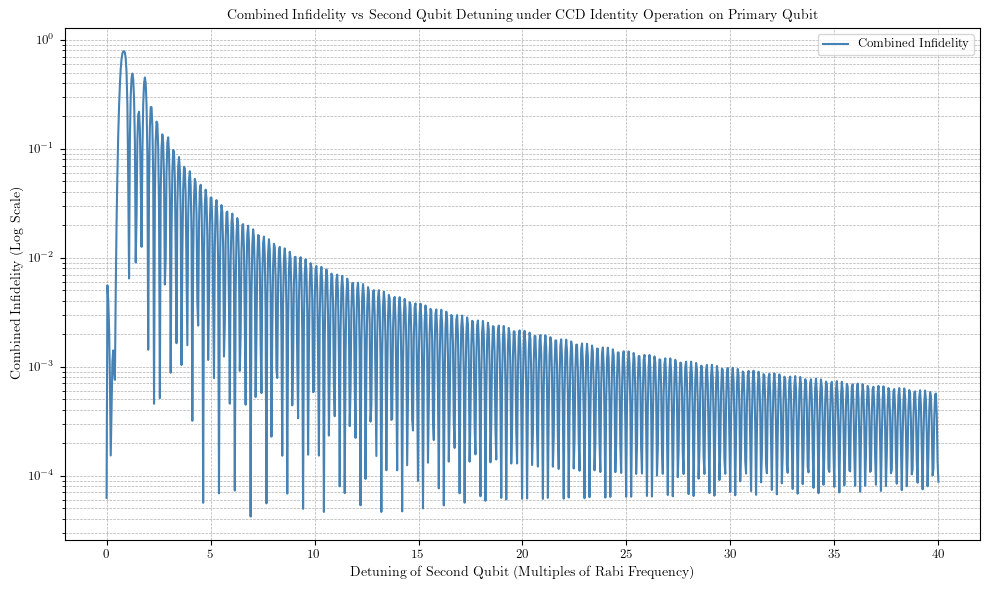

In [ ]:

# find combdined infidelity
infidelities_combined_ccd= 1-np.array(final_fids_combined_ccd)

# Normalize detunings by Rabi frequency
detunings_normalized = detunings / rabi_freq

# Plot combined infidelity vs normalized detuning on a logarithmic scale
plt.figure(figsize=(10, 6))
plt.semilogy(detunings_normalized, infidelities_combined_ccd, label="Combined Infidelity", color=steel_blue)
plt.xlabel("Detuning of Second Qubit (Multiples of Rabi Frequency)")
plt.ylabel("Combined Infidelity (Log Scale)")
plt.title("Combined Infidelity vs Second Qubit Detuning under CCD Identity Operation on Primary Qubit")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


# Rabi

In [ ]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005




# Integration parameters
tol = 10**-12
evaluation_points = 2000
evaluation_time = 4/rabi_freq

# iteration parameters
detunings = np.linspace(0, 100*rabi_freq, 4000)


fids_1 = []
fids_2 = []
fids_combined = []

times, Us_driving_frame = qt.calculate_unitaries(
        1, 
        evaluation_time, 
        evaluation_points, 
        hamiltonians.rabi_rwa, 
        natural_freq=natural_freq, 
        driving_freq=driving_freq, 
        rabi_freq=rabi_freq, 
        atol=tol, 
        rtol=tol
    )
fid_1 = qt.calculate_fidelities(identity, Us_driving_frame, 2)


for detuning in detunings:
    times, Us_driving_frame = qt.calculate_unitaries(
        1, 
        evaluation_time, 
        evaluation_points, 
        hamiltonians.rabi_rwa, 
        natural_freq=natural_freq-detuning, 
        driving_freq=driving_freq, 
        rabi_freq=rabi_freq, 
        atol=tol, 
        rtol=tol
    )
    fids_1.append(fid_1)

    effective_rabi_freq = np.sign(detuning)*np.sqrt(rabi_freq**2 + detuning**2)
    Us_effective_rabi = qt.phase_boost_unitaries(Us_driving_frame, effective_rabi_freq, times)
    fid_2 = qt.calculate_fidelities(identity, Us_effective_rabi, 2)
    fids_2.append(fid_2)

    fid_combined = (np.abs((6*fid_1-2)*(6*fid_2-2))+4)/20
    fids_combined.append(fid_combined)

# Extract the final time step fidelity for each detuning
final_fids_combined_rabi = [fid[-1] for fid in fids_combined]

detunings_normalized = detunings / rabi_freq

KeyboardInterrupt: 

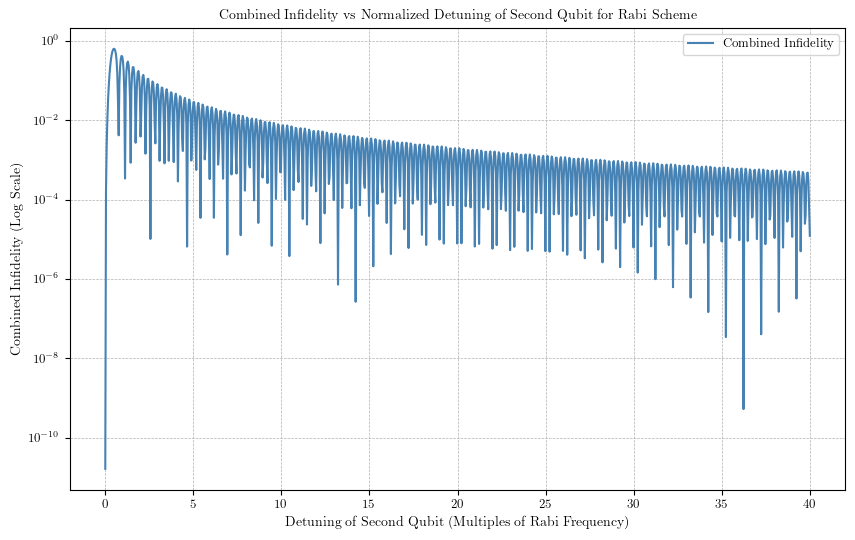

In [10]:
# find combdined infidelity
infidelities_combined_rabi = 1-np.array(final_fids_combined_rabi)

# Normalize detunings by Rabi frequency
detunings_normalized = detunings / rabi_freq

# Plot combined infidelity vs normalized detuning on a logarithmic scale
plt.figure(figsize=(10, 6))
plt.semilogy(detunings_normalized, infidelities_combined_rabi, label="Combined Infidelity", color=steel_blue)
plt.xlabel("Detuning of Second Qubit (Multiples of Rabi Frequency)")
plt.ylabel("Combined Infidelity (Log Scale)")
plt.title("Combined Infidelity vs Normalized Detuning of Second Qubit for Rabi Scheme")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()


# Save the data 

In [36]:
import pandas as pd

infidelities_combined_ccd= 1-np.array(final_fids_combined_ccd)
infidelities_combined_rabi = 1-np.array(final_fids_combined_rabi)




# Create a DataFrame with the data
data = {
    "detunings_normalized": detunings_normalized,
    "infidelities_combined_ccd": infidelities_combined_ccd,
    "infidelities_combined_rabi": infidelities_combined_rabi
}
df = pd.DataFrame(data)

# Save the DataFrame to a CSV file
csv_path = '/Users/archie/documents/year4/project/identity_scaling.csv'
df.to_csv(csv_path, index=False)
print(f"Fidelities and normalized detunings saved successfully to {csv_path}.")

Fidelities and normalized detunings saved successfully to /Users/archie/documents/year4/project/identity_scaling.csv.


# Compare


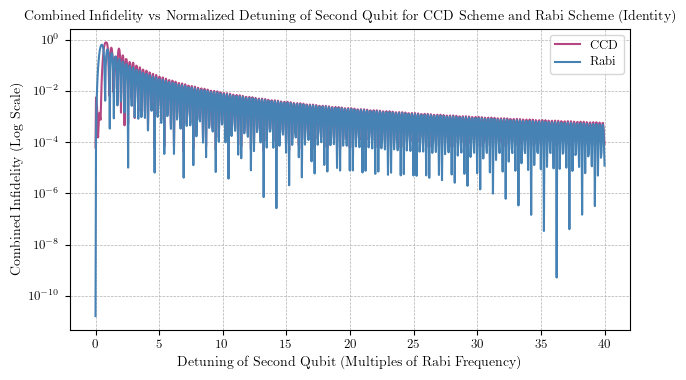

In [12]:
# find combdined infidelity
infidelities_combined_ccd = 1-np.array(final_fids_combined_ccd)
infidelities_combined_rabi = 1-np.array(final_fids_combined_rabi)

# Normalize detunings by Rabi frequency
detunings_normalized = detunings / rabi_freq

# Plot combined infidelity vs normalized detuning on a logarithmic scale
plt.figure(figsize=(latex_fig_width_inches, 0.6*latex_fig_width_inches))
plt.semilogy(detunings_normalized, infidelities_combined_ccd, label="CCD", color=plum)
plt.semilogy(detunings_normalized, infidelities_combined_rabi, label="Rabi", color=steel_blue)
plt.xlabel("Detuning of Second Qubit (Multiples of Rabi Frequency)")
plt.ylabel("Combined Infidelity (Log Scale)")
plt.title("Combined Infidelity vs Normalized Detuning of Second Qubit for CCD Scheme and Rabi Scheme (Identity)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.savefig('/Users/archie/documents/year4/project/Figures_Final/identity_cross_talk_scaling.pdf', dpi=600)
plt.show()




# loglog to quantify the agreement with power law

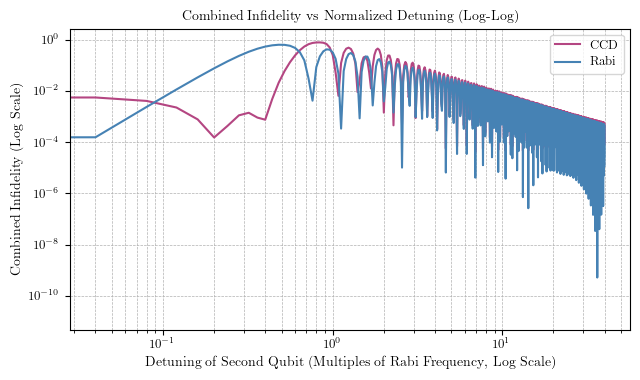

In [ ]:
plt.figure(figsize=(latex_fig_width_inches, 0.6 * latex_fig_width_inches))
plt.loglog(detunings_normalized, infidelities_combined_ccd, label="CCD", color=plum) # Changed here
plt.loglog(detunings_normalized, infidelities_combined_rabi, label="Rabi", color=steel_blue) # Changed here
plt.xlabel("Detuning of Second Qubit (Multiples of Rabi Frequency, Log Scale)") # Added Log Scale to label
plt.ylabel("Combined Infidelity (Log Scale)")
plt.title("Combined Infidelity vs Normalized Detuning (Log-Log)") # Simplified title
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
# plt.savefig('/Users/archie/documents/year4/project/Figures_Final/identity_cross_talk_scaling_loglog.pdf', dpi=600) # Suggested new filename
plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\D'
<>:14: SyntaxWarning: invalid escape sequence '\D'
/var/folders/r1/4bsh28x136nb61xfvz5ly0dh0000gn/T/ipykernel_28707/2301476480.py:14: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel("Normalized Detuning ($\Delta / \Omega$)")


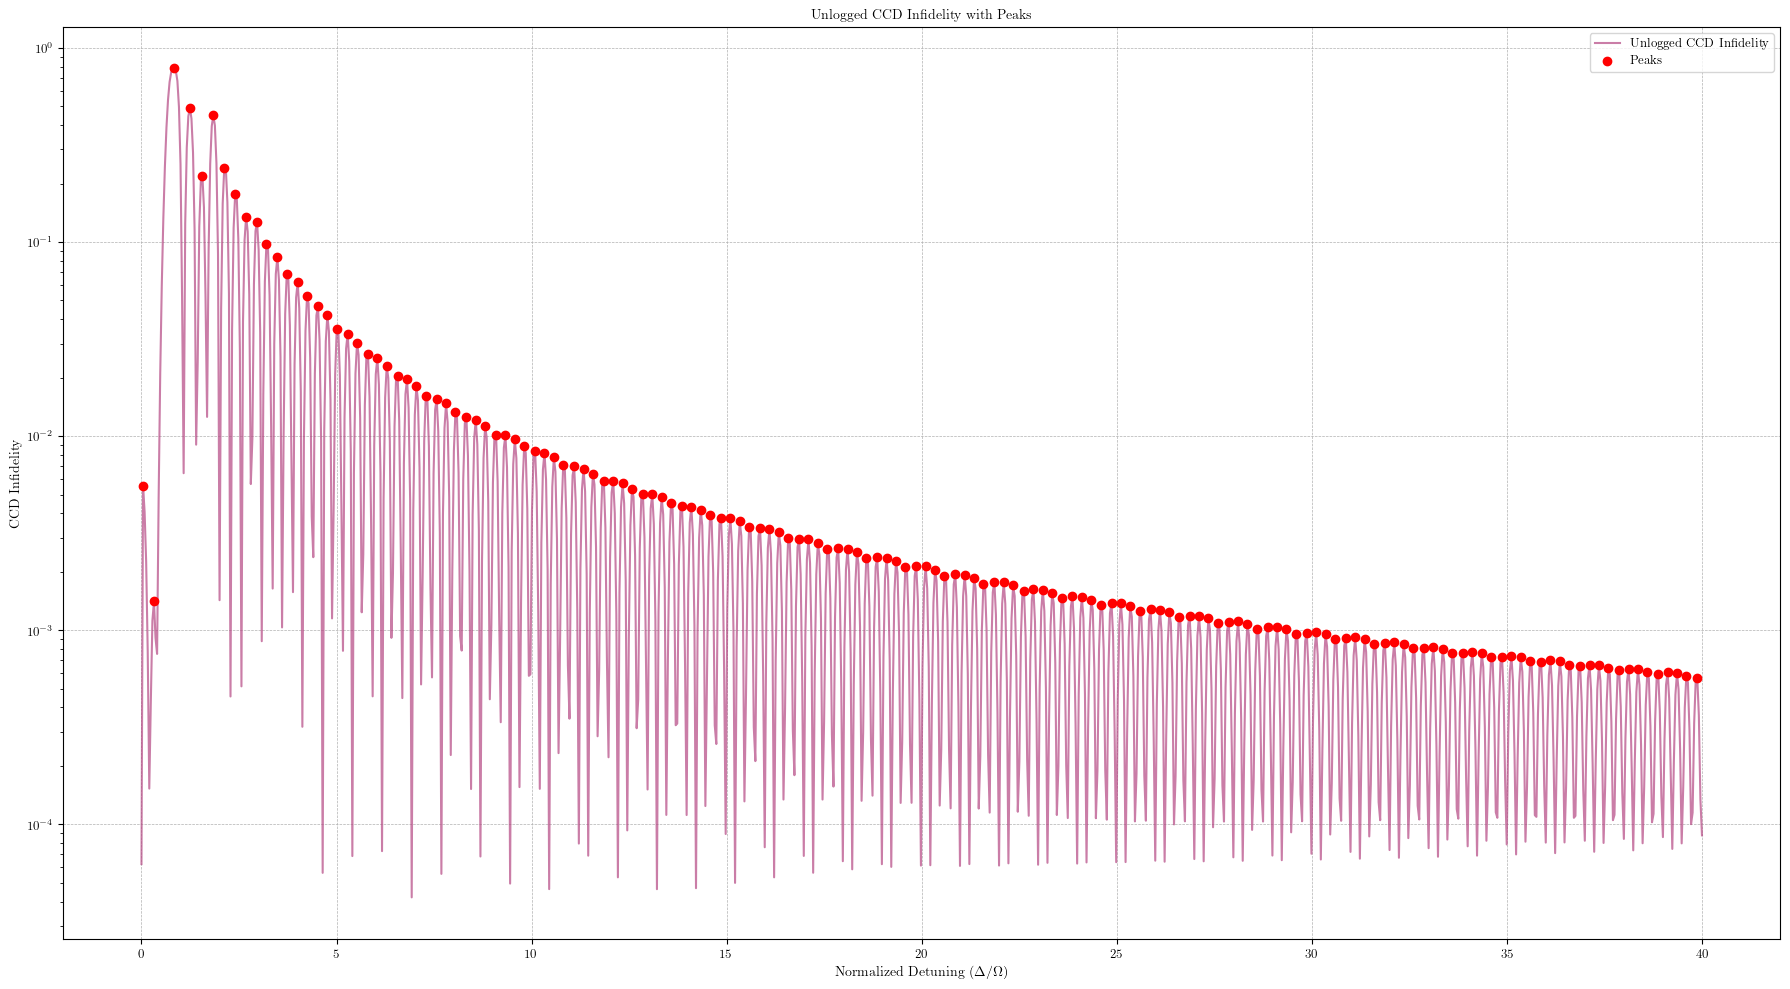

Number of peaks in unlogged CCD infidelity: 157


In [28]:
from scipy.signal import find_peaks

# Find peaks for unlogged CCD infidelity
ccd_peaks, _ = find_peaks(infidelities_combined_ccd, height=1e-5)  # Adjust height as needed

# Extract peak values
ccd_peaks_x = detunings_normalized[ccd_peaks]
ccd_peaks_y = infidelities_combined_ccd[ccd_peaks]

# Plot the original curve and the peaks
plt.figure(figsize=(18,10))
plt.semilogy(detunings_normalized, infidelities_combined_ccd, label="Unlogged CCD Infidelity", color=plum, alpha=0.7)
plt.scatter(ccd_peaks_x, ccd_peaks_y, color="red", label="Peaks", zorder=5)
plt.xlabel("Normalized Detuning ($\Delta / \Omega$)")
plt.ylabel("CCD Infidelity")
plt.title("Unlogged CCD Infidelity with Peaks")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Print the number of peaks
print(f"Number of peaks in unlogged CCD infidelity: {len(ccd_peaks)}")